In [1]:
%matplotlib widget
import h5py
import matplotlib.pyplot as plt
import glob
from pathlib import Path
import numpy as np
import sys
sys.path.append('/dls_sw/e02/software/epsic_tools/epsic_tools/mib2hdfConvert/ptyrex_tools')
from Ptyrex_postprocess import *
from matplotlib.animation import FuncAnimation

In [2]:
root_path = Path('/dls/e02/data/2026/mg44468-1/processing/Merlin/Pt_NP_Overnight_5March2026')


In [3]:
# recon_list =  list(root_path.rglob('*/pty_out/initial_recon/parti*.hdf'))
# len(recon_list)
recon_list =  sorted(list(root_path.rglob('*/pty_out/initial_recon/particle*.hdf')))
len(recon_list)

132

In [4]:
recon_list[0].parts[-4]

'20260305_164923'

In [5]:
probes_phase_list = []
probes_mod_list = []
dataset_ts = []
for _f in recon_list:
    try:
        with h5py.File(_f, 'r') as f:
            probe = f['entry_1']['process_1']['output_1']['probe'][()]
            probe_r = reduce_probes(probe)
            probe_sum = np.sum(probe_r[:,0,:,:], axis=0)
            probe_phase = np.angle(probe_sum)
            probe_mod = np.abs(probe_sum)
            probes_phase_list.append(probe_phase)
            probes_mod_list.append(probe_mod)
            dataset_ts.append(_f.parts[-4])
    except:
        continue

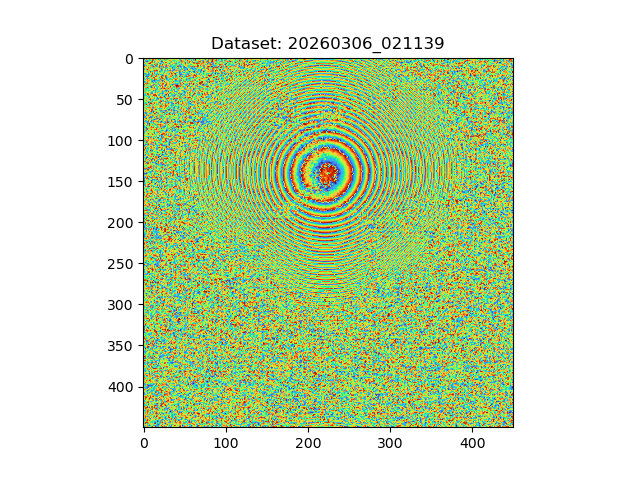

In [6]:
fig, ax = plt.subplots()
im = ax.imshow(probes_phase_list[0], cmap='turbo')

def update(frame):
    # Calculate the calibrated value for the current frame
    # calibrated_value = (frame * scale) + offset
    
    im.set_data(probes_phase_list[frame])
    
    # Update title with units (e.g., "Position: 10.5 nm")
    ax.set_title(f"Dataset: {dataset_ts[frame]}")

    
    return [im]

ani = FuncAnimation(fig, update, frames=len(probes_phase_list), 
                    interval=200, blit=True)

ani.save('particle_probe_phase.gif', writer='pillow')

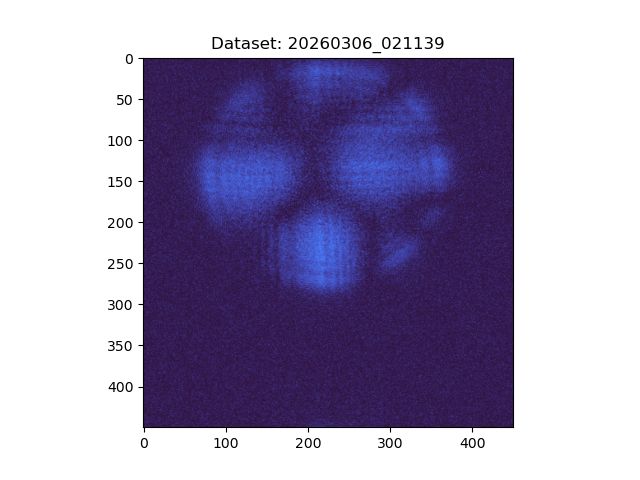

In [8]:
fig, ax = plt.subplots()
im = ax.imshow(probes_mod_list[0], cmap='turbo')

def update(frame):
    # Calculate the calibrated value for the current frame
    # calibrated_value = (frame * scale) + offset
    
    im.set_data(probes_mod_list[frame])
    
    # Update title with units (e.g., "Position: 10.5 nm")
    ax.set_title(f"Dataset: {dataset_ts[frame]}")

    
    return [im]

ani = FuncAnimation(fig, update, frames=len(probes_mod_list), 
                    interval=200, blit=True)

ani.save('particle_probe_mod.gif', writer='pillow')

In [5]:
with h5py.File(recon_list[0], 'r') as f:
    print(f.keys())
    probe = f['entry_1']['process_1']['output_1']['probe_phase'][()]

<KeysViewHDF5 ['entry_1', 'mtime', 'version']>


In [13]:
probe_r = reduce_probes(probe)

In [14]:
probe_r.shape

(4, 5, 450, 450)

In [16]:
probe_sum = np.sum(probe_r[:,0,:,:], axis=0)
probe_sum.shape

(450, 450)

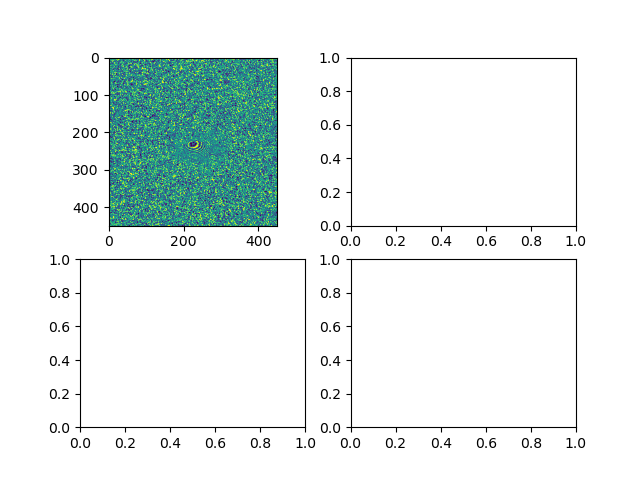

In [17]:
fig, axs = plt.subplots(2,2)
axs[0,0].imshow(np.angle(probe_sum))
# plt.imshow(np.angle(probe[3, 0, 0, 0, 0, :, :]))